# Conformal STL interface intersections — visual diagnostic

This notebook visualizes the geometric STL intersections computed by the conformal geometry pipeline for the standard WAKIS cavity/shell example.

The purpose is to compare, in a 2D slice,

- the **actual STL cross-section**,
- the **primal or dual FIT grid edges**,
- the **endpoint-based interface edges**, and
- the **geometrically computed STL intersection points**.

The same visualization is produced for the **primal** and **dual** grids.

A useful visual result is that the intersection markers lie on the sliced STL curves. The plot also makes it possible to spot endpoint interfaces without a geometric hit, geometric intersections invisible to endpoint classification, and edges containing multiple intersections.


## 1. Imports and STL paths

In [1]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import numpy as np
import pyvista as pv

from wakis.gridFIT3D import GridFIT3D


cavity_stl = "../tests/stl/007_vacuum_cavity.stl"
shell_stl = "../tests/stl/007_lossymetal_shell.stl"

## 2. Build the conformal cavity/shell grid

The resolution below is intentionally moderate. It is sufficient for a visual diagnostic while keeping the geometric line tracing reasonably fast.

`GridFIT3D(..., geometry_mode="conformal")` builds the primal and dual point classifications, region topology, endpoint-interface masks, and geometric STL intersections.


In [2]:
stl_solids = {
    "cavity": cavity_stl,
    "shell": shell_stl,
}

stl_materials = {
    "cavity": "vacuum",
    "shell": [30.0, 1.0, 30.0],
}

# Geometry diagnostic only: both STL regions use normal treatment here.
stl_material_types = {
    "cavity": "normal",
    "shell": "normal",
}

combined_surface = pv.read(cavity_stl) + pv.read(shell_stl)
xmin, xmax, ymin, ymax, zmin, zmax = combined_surface.bounds

Nx = 20
Ny = 20
Nz = 40

grid = GridFIT3D(
    xmin,
    xmax,
    ymin,
    ymax,
    zmin,
    zmax,
    Nx,
    Ny,
    Nz,
    stl_solids=stl_solids,
    stl_materials=stl_materials,
    stl_material_types=stl_material_types,
    stl_method="voxelize_rectilinear",
    geometry_mode="conformal",
    subpixel_smoothing=False,
    stl_scale=1.0,
    stl_rotate=[0.0, 0.0, 0.0],
    stl_translate=[0.0, 0.0, 0.0],
    verbose=1,
)

assert grid.interface_intersections["primal"]
assert grid.interface_intersections["dual"]

Generating grid with 16000 mesh cells...
Importing STL solids...
 * Marking grid points inside STL solid 'cavity'...
    * STL solid cavity: 3892 primal points, 3528 cell centers, and 3861 dual points marked inside the solid.
 * Marking grid points inside STL solid 'shell'...
    * STL solid shell: 1844 primal points, 1048 cell centers, and 1896 dual points marked inside the solid.
    * primal x-edges: 1762 geometric hits, 1762 crossings, 0 contacts, 366 with multiple crossing positions
    * primal y-edges: 1764 geometric hits, 1764 crossings, 0 contacts, 386 with multiple crossing positions
    * primal z-edges: 1058 geometric hits, 1057 crossings, 1 contacts, 362 with multiple crossing positions
    * dual x-edges: 1674 geometric hits, 1674 crossings, 0 contacts, 352 with multiple crossing positions
    * dual y-edges: 1674 geometric hits, 1674 crossings, 0 contacts, 377 with multiple crossing positions
    * dual z-edges: 1064 geometric hits, 1064 crossings, 0 contacts, 394 with m

## 3. Load the transformed STL surfaces

In [3]:
# Use GridFIT3D.read_stl() so the plotted geometry uses exactly the
# same transformations as the geometry pipeline.
surfaces = {key: grid.read_stl(key) for key in grid.stl_solids}

## 4. Numerical summary

The endpoint topology, raw geometric hits, and physical crossings are deliberately different concepts:

- **endpoint**: the two edge endpoints have different region IDs,
- **geometric hit**: STL ray tracing found at least one surface hit on the edge,
- **crossing**: at least one STL surface is actually crossed by the edge,
- **contact**: the edge touches or runs tangentially/coplanarly along an STL surface,
- **missing**: endpoint classification predicts an interface but no crossing was found,
- **hidden**: a crossing was found although both endpoints have the same effective region,
- **multiple crossing positions**: more than one distinct crossing position lies on one edge.


In [13]:
def intersection_summary(grid):
    rows = []

    for grid_type in ("primal", "dual"):
        for direction in ("x", "y", "z"):
            endpoint_mask = grid.interface_edge_masks[grid_type][direction]
            data = grid.interface_intersections[grid_type][direction]

            geometric_mask = data["has_intersection"]
            crossing_mask = data["has_crossing"]
            contact_mask = data["has_contact"]
            multiple_crossing_mask = data["multiple_crossing_positions"]

            missing_mask = endpoint_mask & ~crossing_mask
            hidden_mask = crossing_mask & ~endpoint_mask

            rows.append(
                (
                    grid_type,
                    direction,
                    int(np.count_nonzero(endpoint_mask)),
                    int(np.count_nonzero(geometric_mask)),
                    int(np.count_nonzero(crossing_mask)),
                    int(np.count_nonzero(contact_mask)),
                    int(np.count_nonzero(missing_mask)),
                    int(np.count_nonzero(hidden_mask)),
                    int(np.count_nonzero(multiple_crossing_mask)),
                )
            )

    header = (
        "grid",
        "dir",
        "endpoint",
        "geometric",
        "crossing",
        "contact",
        "missing",
        "hidden",
        "multiple",
    )

    widths = [
        max(len(str(row[i])) for row in [header, *rows]) for i in range(len(header))
    ]

    def format_row(row):
        return "  ".join(str(value).rjust(width) for value, width in zip(row, widths))

    print(format_row(header))
    print(format_row(tuple("-" * width for width in widths)))

    for row in rows:
        print(format_row(row))


intersection_summary(grid)


def multiple_crossing_summary(grid):
    rows = []

    for grid_type in ("primal", "dual"):
        for direction in ("x", "y", "z"):
            data = grid.interface_intersections[grid_type][direction]

            n_multiple = 0
            n_repeated_same_stl = 0
            n_different_stls_only = 0

            for index, groups in data["crossing_groups"].items():
                if len(groups) <= 1:
                    continue

                n_multiple += 1

                surface_ids_per_group = [
                    {hit["surface_id"] for hit in group} for group in groups
                ]

                all_surface_ids = set().union(*surface_ids_per_group)

                repeated_surface_ids = {
                    surface_id
                    for surface_id in all_surface_ids
                    if sum(
                        surface_id in group_ids for group_ids in surface_ids_per_group
                    )
                    > 1
                }

                if repeated_surface_ids:
                    n_repeated_same_stl += 1
                else:
                    n_different_stls_only += 1

            rows.append(
                (
                    grid_type,
                    direction,
                    n_multiple,
                    n_repeated_same_stl,
                    n_different_stls_only,
                )
            )

    header = (
        "grid",
        "dir",
        "multiple",
        "same STL repeated",
        "different STLs only",
    )

    widths = [
        max(len(str(row[i])) for row in [header, *rows]) for i in range(len(header))
    ]

    def format_row(row):
        return "  ".join(str(value).rjust(width) for value, width in zip(row, widths))

    print("Multiple-crossing classification")
    print(format_row(header))
    print(format_row(tuple("-" * width for width in widths)))

    for row in rows:
        print(format_row(row))


def hidden_crossing_summary(grid, alpha_tolerance=1e-8):
    rows = []

    for grid_type in ("primal", "dual"):
        for direction in ("x", "y", "z"):
            endpoint_mask = grid.interface_edge_masks[grid_type][direction]

            data = grid.interface_intersections[grid_type][direction]

            n_hidden = 0
            n_at_alpha_0 = 0
            n_at_alpha_1 = 0
            n_strictly_inside = 0

            for index, groups in data["crossing_groups"].items():
                if endpoint_mask[index]:
                    continue

                for group in groups:
                    alpha = float(np.mean([hit["alpha"] for hit in group]))

                    n_hidden += 1

                    if abs(alpha) <= alpha_tolerance:
                        n_at_alpha_0 += 1

                    elif abs(alpha - 1.0) <= alpha_tolerance:
                        n_at_alpha_1 += 1

                    else:
                        n_strictly_inside += 1

            rows.append(
                (
                    grid_type,
                    direction,
                    n_hidden,
                    n_at_alpha_0,
                    n_at_alpha_1,
                    n_strictly_inside,
                )
            )

    header = (
        "grid",
        "dir",
        "hidden crossings",
        "alpha = 0",
        "alpha = 1",
        "0 < alpha < 1",
    )

    widths = [
        max(len(str(row[i])) for row in [header, *rows]) for i in range(len(header))
    ]

    def format_row(row):
        return "  ".join(str(value).rjust(width) for value, width in zip(row, widths))

    print()
    print("Hidden-crossing position diagnostic")
    print(format_row(header))
    print(format_row(tuple("-" * width for width in widths)))

    for row in rows:
        print(format_row(row))


multiple_crossing_summary(grid)
hidden_crossing_summary(grid)

  grid  dir  endpoint  geometric  crossing  contact  missing  hidden  multiple
------  ---  --------  ---------  --------  -------  -------  ------  --------
primal    x      1738       1762      1762        0       10      34       366
primal    y      1738       1764      1764        0        8      34       386
primal    z      1021       1058      1057        1        1      37       362
  dual    x      1672       1674      1674        0       11      13       352
  dual    y      1666       1674      1674        0        8      16       377
  dual    z      1051       1064      1064        0        0      13       394
Multiple-crossing classification
  grid  dir  multiple  same STL repeated  different STLs only
------  ---  --------  -----------------  -------------------
primal    x       366                  0                  366
primal    y       386                  0                  386
primal    z       362                  0                  362
  dual    x       352    

## 5. Plotting helpers

The plotting functions use **all geometric hit groups**, not just the single representative intersection stored in the dense arrays. Therefore an edge with two distinct intersections produces two `×` markers.


In [12]:
plot_colors = {
    "grid": "0.82",
    "endpoint": "0.35",
    "cavity": "tab:orange",
    "shell": "tab:green",
    "crossing": "tab:blue",
    "contact": "tab:brown",
    "hidden": "tab:purple",
    "multiple": "tab:red",
}


def grid_coordinates(grid_type):
    if grid_type == "primal":
        return np.asarray(grid.x), np.asarray(grid.y), np.asarray(grid.z)
    if grid_type == "dual":
        return np.asarray(grid.tx), np.asarray(grid.ty), np.asarray(grid.tz)
    raise ValueError(f"Unknown grid type: {grid_type}")


def plane_info(plane):
    definitions = {
        "xy": {
            "fixed_axis": 2,
            "plot_axes": (0, 1),
            "directions": ("x", "y"),
            "labels": ("x [m]", "y [m]"),
            "fixed_label": "z",
        },
        "xz": {
            "fixed_axis": 1,
            "plot_axes": (0, 2),
            "directions": ("x", "z"),
            "labels": ("x [m]", "z [m]"),
            "fixed_label": "y",
        },
        "yz": {
            "fixed_axis": 0,
            "plot_axes": (1, 2),
            "directions": ("y", "z"),
            "labels": ("y [m]", "z [m]"),
            "fixed_label": "x",
        },
    }
    if plane not in definitions:
        raise ValueError("plane must be 'xy', 'xz', or 'yz'")
    return definitions[plane]


def nearest_slice(grid_type, plane, requested_value):
    coordinates = grid_coordinates(grid_type)
    fixed_coordinates = coordinates[plane_info(plane)["fixed_axis"]]
    index = int(np.argmin(np.abs(fixed_coordinates - requested_value)))
    return index, float(fixed_coordinates[index])


def project_point(point, plane):
    axes = plane_info(plane)["plot_axes"]
    point = np.asarray(point, dtype=float)
    return point[list(axes)]


def slice_surface(surface, plane, value):
    info = plane_info(plane)
    origin = np.zeros(3)
    origin[info["fixed_axis"]] = value
    normal = np.zeros(3)
    normal[info["fixed_axis"]] = 1.0
    return surface.slice(origin=origin, normal=normal)


def plot_polydata_lines(ax, polydata, plane, color, linewidth=1.8):
    if polydata.n_cells == 0:
        return

    for cell_id in range(polydata.n_cells):
        cell = polydata.get_cell(cell_id)
        points = np.asarray(cell.points, dtype=float)

        if len(points) < 2:
            continue

        projected = np.asarray([project_point(point, plane) for point in points])

        ax.plot(
            projected[:, 0],
            projected[:, 1],
            color=color,
            linewidth=linewidth,
            zorder=3,
        )


def edge_is_in_slice(index, plane, slice_index):
    i, j, k = index

    if plane == "xy":
        return k == slice_index
    if plane == "xz":
        return j == slice_index
    if plane == "yz":
        return i == slice_index

    raise ValueError("plane must be 'xy', 'xz', or 'yz'")


def edge_segment(grid_type, direction, index, plane):
    p0, p1, _, _ = grid._get_edge_geometry(
        grid_type,
        direction,
        index,
    )

    return np.asarray(
        [
            project_point(p0, plane),
            project_point(p1, plane),
        ]
    )


def collect_full_grid_segments(grid_type, plane, slice_index):
    segments = []

    for direction in plane_info(plane)["directions"]:
        shape = grid.interface_intersections[grid_type][direction][
            "has_intersection"
        ].shape

        for index in np.ndindex(shape):
            if edge_is_in_slice(index, plane, slice_index):
                segments.append(
                    edge_segment(
                        grid_type,
                        direction,
                        index,
                        plane,
                    )
                )

    return segments


def collect_endpoint_interface_segments(grid_type, plane, slice_index):
    segments = []

    for direction in plane_info(plane)["directions"]:
        mask = grid.interface_edge_masks[grid_type][direction]

        for raw_index in np.argwhere(mask):
            index = tuple(int(v) for v in raw_index)

            if edge_is_in_slice(index, plane, slice_index):
                segments.append(
                    edge_segment(
                        grid_type,
                        direction,
                        index,
                        plane,
                    )
                )

    return segments


def collect_intersection_points(grid_type, plane, slice_index):
    crossings = []
    contacts = []
    hidden = []
    multiple = []

    for direction in plane_info(plane)["directions"]:
        data = grid.interface_intersections[grid_type][direction]
        endpoint_mask = grid.interface_edge_masks[grid_type][direction]

        edge_indices = set(data["crossing_groups"]) | set(data["contact_groups"])

        for index in edge_indices:
            index = tuple(int(v) for v in index)

            if not edge_is_in_slice(
                index,
                plane,
                slice_index,
            ):
                continue

            p0, p1, _, _ = grid._get_edge_geometry(
                grid_type,
                direction,
                index,
            )

            p0 = np.asarray(p0, dtype=float)
            p1 = np.asarray(p1, dtype=float)

            crossing_groups = data["crossing_groups"].get(
                index,
                [],
            )

            crossing_points = []

            for group in crossing_groups:
                alpha = float(np.mean([hit["alpha"] for hit in group]))

                point = p0 + alpha * (p1 - p0)
                projected = project_point(point, plane)

                crossings.append(projected)
                crossing_points.append(projected)

                if not endpoint_mask[index]:
                    hidden.append(projected)

            if len(crossing_groups) > 1:
                multiple.extend(crossing_points)

            contact_groups = data["contact_groups"].get(
                index,
                [],
            )

            for group in contact_groups:
                alpha = float(np.mean([hit["alpha"] for hit in group]))

                point = p0 + alpha * (p1 - p0)

                contacts.append(
                    project_point(
                        point,
                        plane,
                    )
                )

    def as_array(values):
        if not values:
            return np.empty((0, 2), dtype=float)

        return np.asarray(
            values,
            dtype=float,
        )

    return {
        "crossings": as_array(crossings),
        "contacts": as_array(contacts),
        "hidden": as_array(hidden),
        "multiple": as_array(multiple),
    }

    def as_array(values):
        if not values:
            return np.empty((0, 2), dtype=float)
        return np.asarray(values, dtype=float)

    return {
        "all": as_array(points),
        "hidden": as_array(hidden),
        "multiple": as_array(multiple),
    }

## 6. Plot one primal or dual slice

Plot semantics:

- **FIT grid edges**: all primal or dual FIT edges in the selected 2D plane.
- **Endpoint interface edges**: edges whose two endpoint region IDs differ.
- **STL contours**: the actual cross-sections of the transformed STL surfaces.
- **Crossing intersections**: geometric positions where an STL surface is actually crossed.
- **Tangential/coplanar contacts**: geometric hits where the edge does not cross the surface.
- **Hidden from endpoint topology**: crossings on edges whose endpoints have the same region ID.
- **Multiple crossing positions**: crossing positions belonging to an edge with more than one distinct crossing position.

Hidden and multiple markers are overlays on top of the ordinary crossing markers.


In [8]:
def plot_interface_slice(
    grid_type,
    plane="xz",
    slice_value=None,
    show_full_grid=True,
    show_hidden=True,
    show_contacts=True,
    show_multiple=True,
    ax=None,
):
    x, y, z = grid_coordinates(grid_type)

    if slice_value is None:
        bounds = {
            "xy": (z[0], z[-1]),
            "xz": (y[0], y[-1]),
            "yz": (x[0], x[-1]),
        }[plane]

        slice_value = 0.5 * (bounds[0] + bounds[1])

    slice_index, actual_value = nearest_slice(
        grid_type,
        plane,
        slice_value,
    )

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    # --------------------------------------------------------------
    # Complete FIT grid in the selected plane
    # --------------------------------------------------------------
    if show_full_grid:
        grid_segments = collect_full_grid_segments(
            grid_type,
            plane,
            slice_index,
        )

        if grid_segments:
            ax.add_collection(
                LineCollection(
                    grid_segments,
                    colors=plot_colors["grid"],
                    linewidths=0.6,
                    alpha=0.7,
                    zorder=1,
                )
            )

    # --------------------------------------------------------------
    # Endpoint-detected interface edges
    # --------------------------------------------------------------
    interface_segments = collect_endpoint_interface_segments(
        grid_type,
        plane,
        slice_index,
    )

    if interface_segments:
        ax.add_collection(
            LineCollection(
                interface_segments,
                colors=plot_colors["endpoint"],
                linewidths=1.8,
                alpha=0.85,
                zorder=2,
            )
        )

    # --------------------------------------------------------------
    # Exact STL cross-sections
    # --------------------------------------------------------------
    for key, surface in surfaces.items():
        sliced = slice_surface(
            surface,
            plane,
            actual_value,
        )

        plot_polydata_lines(
            ax,
            sliced,
            plane,
            color=plot_colors[key],
            linewidth=2.0,
        )

    # --------------------------------------------------------------
    # Classified geometric intersections
    # --------------------------------------------------------------
    intersection_points = collect_intersection_points(
        grid_type,
        plane,
        slice_index,
    )

    crossings = intersection_points["crossings"]

    if len(crossings):
        ax.scatter(
            crossings[:, 0],
            crossings[:, 1],
            marker="x",
            s=42,
            color=plot_colors["crossing"],
            linewidths=1.4,
            zorder=5,
        )

    contacts = intersection_points["contacts"]

    if show_contacts and len(contacts):
        ax.scatter(
            contacts[:, 0],
            contacts[:, 1],
            marker="s",
            s=48,
            facecolors="none",
            edgecolors=plot_colors["contact"],
            linewidths=1.4,
            zorder=5,
        )

    hidden = intersection_points["hidden"]

    if show_hidden and len(hidden):
        ax.scatter(
            hidden[:, 0],
            hidden[:, 1],
            marker="o",
            s=72,
            facecolors="none",
            edgecolors=plot_colors["hidden"],
            linewidths=1.4,
            zorder=6,
        )

    multiple = intersection_points["multiple"]

    if show_multiple and len(multiple):
        ax.scatter(
            multiple[:, 0],
            multiple[:, 1],
            marker="+",
            s=105,
            color=plot_colors["multiple"],
            linewidths=1.5,
            zorder=7,
        )

    info = plane_info(plane)

    ax.set_xlabel(info["labels"][0])
    ax.set_ylabel(info["labels"][1])

    ax.set_title(
        f"{grid_type.capitalize()} grid — {plane.upper()} slice, "
        f"{info['fixed_label']} = {actual_value:.6g} m"
    )

    ax.set_aspect("equal")
    ax.autoscale()
    ax.margins(0.03)

    return {
        "slice_index": slice_index,
        "slice_value": actual_value,
        "intersection_points": intersection_points,
    }

## 7. Side-by-side primal and dual view

The requested physical slice coordinate is the same for both panels. Because primal and dual grid planes are staggered, each panel uses the nearest plane available on that grid. The actual coordinate used is written in the title.


In [9]:
def plot_primal_dual(
    plane="xz",
    slice_value=None,
    show_full_grid=True,
):
    if slice_value is None:
        center = {
            "xy": 0.5 * (zmin + zmax),
            "xz": 0.5 * (ymin + ymax),
            "yz": 0.5 * (xmin + xmax),
        }
        slice_value = center[plane]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
    )

    primal_result = plot_interface_slice(
        "primal",
        plane=plane,
        slice_value=slice_value,
        show_full_grid=show_full_grid,
        ax=axes[0],
    )

    dual_result = plot_interface_slice(
        "dual",
        plane=plane,
        slice_value=slice_value,
        show_full_grid=show_full_grid,
        ax=axes[1],
    )

    fig.suptitle(f"Conformal STL intersections — {plane.upper()} view")

    # Leave space between both panels for one shared legend.
    fig.subplots_adjust(
        left=0.06,
        right=0.98,
        bottom=0.10,
        top=0.90,
        wspace=0.62,
    )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=plot_colors["grid"],
            linewidth=1.5,
            label="FIT grid edges",
        ),
        Line2D(
            [0],
            [0],
            color=plot_colors["endpoint"],
            linewidth=2.0,
            label="endpoint interface edges",
        ),
        Line2D(
            [0],
            [0],
            color=plot_colors["cavity"],
            linewidth=2.0,
            label="STL: cavity",
        ),
        Line2D(
            [0],
            [0],
            color=plot_colors["shell"],
            linewidth=2.0,
            label="STL: shell",
        ),
        Line2D(
            [0],
            [0],
            marker="x",
            linestyle="None",
            color=plot_colors["crossing"],
            markersize=7,
            markeredgewidth=1.4,
            label="crossing intersections",
        ),
        Line2D(
            [0],
            [0],
            marker="s",
            linestyle="None",
            markerfacecolor="none",
            markeredgecolor=plot_colors["contact"],
            markersize=7,
            markeredgewidth=1.4,
            label="tangential/coplanar contacts",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markerfacecolor="none",
            markeredgecolor=plot_colors["hidden"],
            markersize=7,
            markeredgewidth=1.4,
            label="hidden from endpoint topology",
        ),
        Line2D(
            [0],
            [0],
            marker="+",
            linestyle="None",
            color=plot_colors["multiple"],
            markersize=9,
            markeredgewidth=1.5,
            label="multiple crossing positions",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="center",
        bbox_to_anchor=(0.5, 0.50),
        frameon=False,
        fontsize=9,
    )

    return {
        "primal": primal_result,
        "dual": dual_result,
    }

## 8. Main visual diagnostic: central XZ section

For the cavity/shell geometry, the longitudinal `XZ` section is usually the most informative first view.


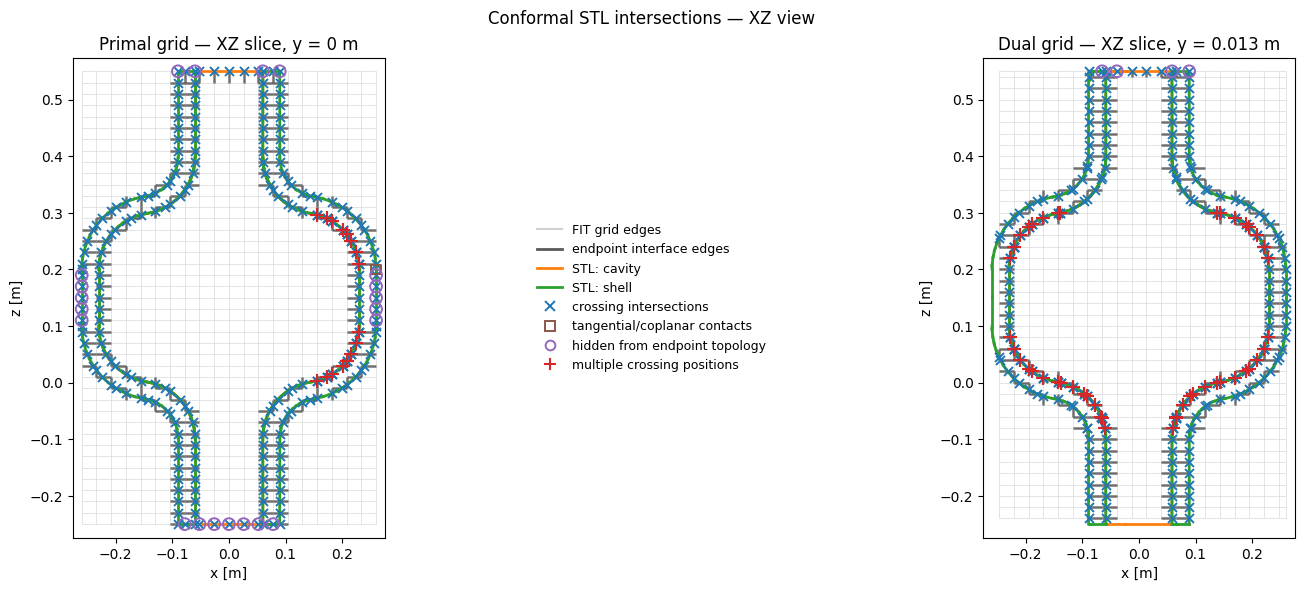

In [10]:
result_xz = plot_primal_dual(
    plane="xz",
    slice_value=0.5 * (ymin + ymax),
)
plt.show()

## 9. Optional transverse and orthogonal views

Uncomment either example to inspect the other slice orientations.


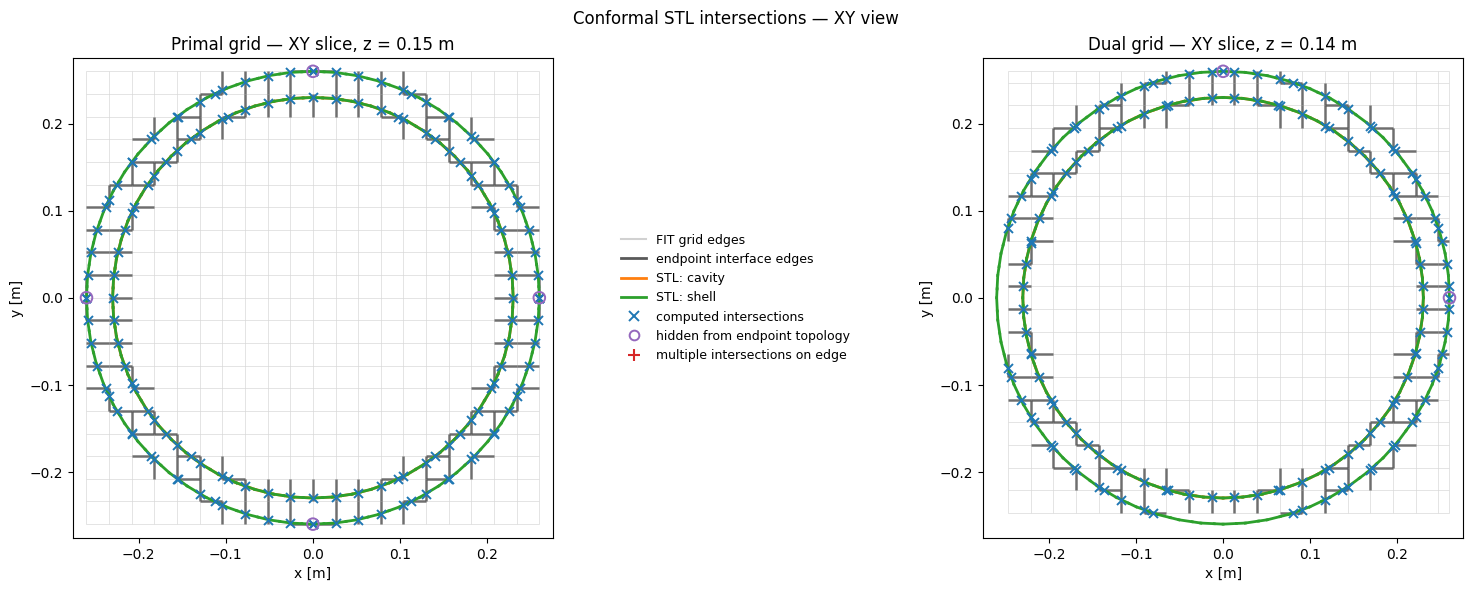

In [11]:
# Central XY plane
result_xy = plot_primal_dual(
    plane="xy",
    slice_value=0.5 * (zmin + zmax),
)
plt.show()

In [ ]:
# Central YZ plane
# result_yz = plot_primal_dual(
#     plane="yz",
#     slice_value=0.5 * (xmin + xmax),
# )
# plt.show()


## 10. Optional local zoom

This final cell is useful for inspecting a beam-pipe/cavity transition or another local region in more detail. Set `xlim` and `ylim` after the first run.


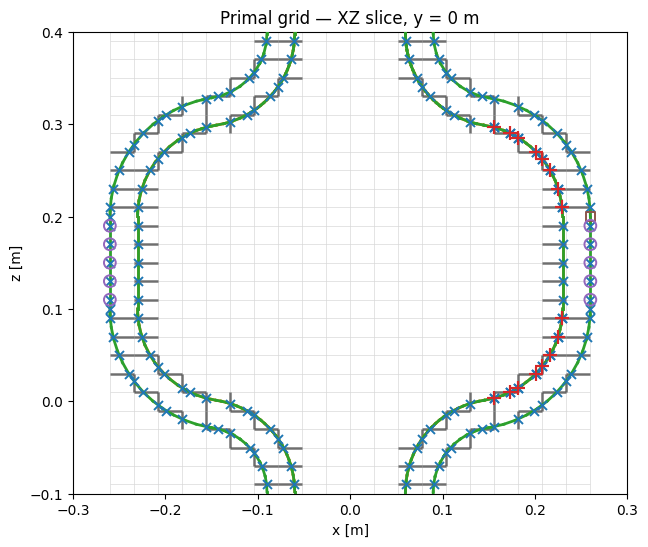

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_interface_slice(
    "primal",
    plane="xz",
    slice_value=0.5 * (ymin + ymax),
    show_full_grid=True,
    ax=ax,
)

# Example zoom limits:
ax.set_xlim(-0.3, 0.3)
ax.set_ylim(-0.1, 0.4)

plt.show()